In [249]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import representations as rep
from data_operations import preprocess_dataset_update
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [250]:
preprocess_dataset_update('datasets/unsupervised', 'datasets/unsupervised.pkl')

File datasets/unsupervised.pkl exists, will update it...


In [251]:
df, titles, albums = rep.create_feature_dataset("./datasets/unsupervised.pkl")

100%|██████████| 98/98 [01:09<00:00,  1.42it/s]


In [252]:
df

array([[-27.550915  , -43.099007  , -10.897662  , ...,  54.50982   ,
         53.931755  ,  53.199215  ],
       [  0.38516858, -18.73874   , -15.319758  , ...,  61.065136  ,
         60.16082   ,  58.6503    ],
       [-68.466484  , -20.741537  ,   1.3294444 , ...,  40.05237   ,
         40.435963  ,  38.322678  ],
       ...,
       [-35.209713  ,  -5.6809225 ,   7.2793746 , ...,  50.172497  ,
         49.75606   ,  48.962784  ],
       [-52.902115  , -28.81674   ,  13.723401  , ...,  21.809475  ,
         21.42918   ,  21.591213  ],
       [-21.750208  , -17.831184  ,   5.3907104 , ...,  55.445934  ,
         55.681404  ,  55.4543    ]], shape=(98, 123), dtype=float32)

In [253]:
titles

['Happy Birthday To You - THE KIBOOMERS Birthday Party Song for Kids.mp3',
 'Grand Theft Auto IV Theme Song ＊[best quality]＊.mp3',
 'Paluch-Nowy Trueschool (Nightcore).mp3',
 'U 96 - Club Bizarre.mp3',
 'Nirvana - Smells Like Teen Spirit (Official Music Video).mp3',
 'Gang Albanii - Albański raj.mp3',
 'Chopin – Waltz in A minor, B. 150, Op. Posth..mp3',
 'Rocky Balboa - Theme Song (HD).mp3',
 'Ciao ciao Siciliano.mp3',
 '4 Raws.mp3',
 'Bedoes & Kubi Producent ft. Koldi, Young Multi, Beteo - Delfin.mp3',
 'The Girl From Ipanema.mp3',
 'Malik Montana - Baciata [Official Music Video].mp3',
 'ROGAL DDL - EBE EBE ⧸ SZYMON TUR & WOWO.mp3',
 'Noc.mp3',
 'Dmitri Shostakovich - Waltz No. 2.mp3',
 'Chief Keef - Love Sosa.mp3',
 'Yunchan Lim - Liszt： Liebestraum No.3 [Live].mp3',
 'Chopin - Waltz in C Sharp Minor (Op. 64 No. 2).mp3',
 'White 2115 - Mogę dziś umierać (prod. Chivas).mp3',
 'White 2115 - Noc [official video].mp3',
 'Tchaikovsky - Swan Lake (Swan Theme).mp3',
 'Tchaikovsky – Swan La

# Data preprocessing

In [254]:
X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original dim:", X.shape[1])
print("After PCA:", X_pca.shape[1])

Original dim: 123
After PCA: 25


# Spróbujmy na początku zastosować kmeans, wybierzemy k metodą łokcia oraz stilhuette score

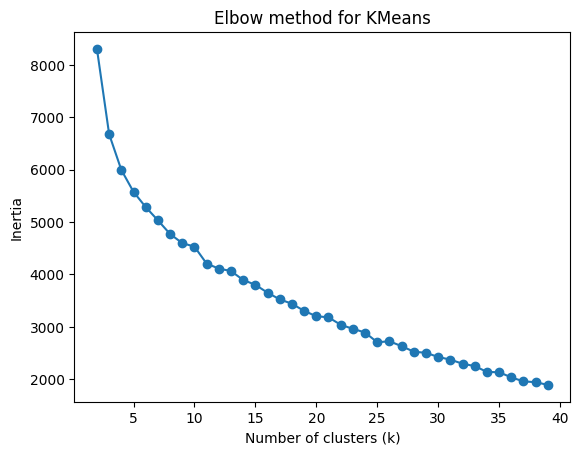

In [255]:
inertias = []
sil_scores = []
k_range = range(2, 40)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    sil_scores.append(score)

plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method for KMeans")
plt.show()

# Na oko najlepszym wyborem wydaje się k = 6/7

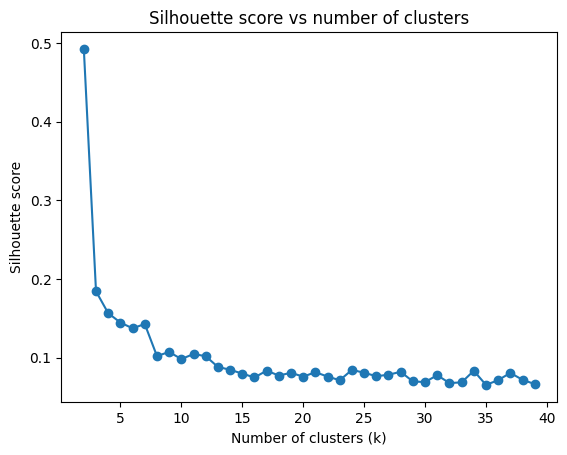

In [256]:
plt.plot(k_range, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs number of clusters")
plt.show()

### tutaj też 6-7 wygląda dobrze, wybierzmy 6

In [257]:
kmeans = KMeans(n_clusters=6, n_init=30, random_state=42)
clusters = kmeans.fit_predict(X_pca)

In [258]:
tsne = TSNE(
    n_components=2,
    perplexity=25,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

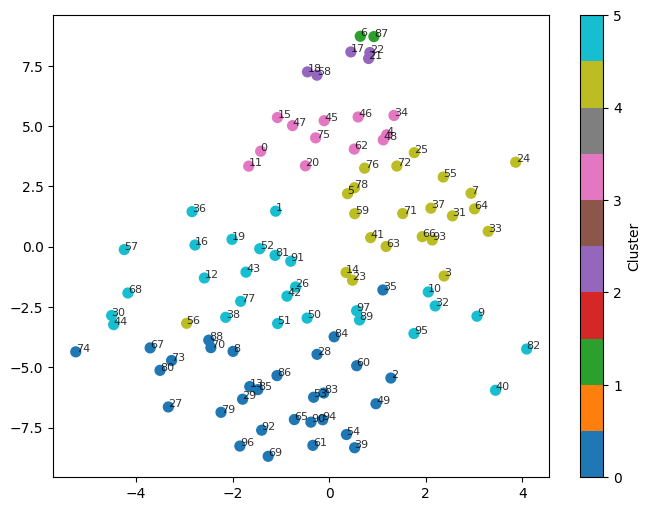

In [259]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='tab10', s=50)

for i in range(len(X_tsne)):
    plt.text(X_tsne[i, 0], X_tsne[i, 1], str(i), fontsize=8, alpha=0.8)

plt.colorbar(label="Cluster")
plt.show()

In [260]:
for i, t in enumerate(titles):
    print(f"{i:02d} | {t}")

00 | Happy Birthday To You - THE KIBOOMERS Birthday Party Song for Kids.mp3
01 | Grand Theft Auto IV Theme Song ＊[best quality]＊.mp3
02 | Paluch-Nowy Trueschool (Nightcore).mp3
03 | U 96 - Club Bizarre.mp3
04 | Nirvana - Smells Like Teen Spirit (Official Music Video).mp3
05 | Gang Albanii - Albański raj.mp3
06 | Chopin – Waltz in A minor, B. 150, Op. Posth..mp3
07 | Rocky Balboa - Theme Song (HD).mp3
08 | Ciao ciao Siciliano.mp3
09 | 4 Raws.mp3
10 | Bedoes & Kubi Producent ft. Koldi, Young Multi, Beteo - Delfin.mp3
11 | The Girl From Ipanema.mp3
12 | Malik Montana - Baciata [Official Music Video].mp3
13 | ROGAL DDL - EBE EBE ⧸ SZYMON TUR & WOWO.mp3
14 | Noc.mp3
15 | Dmitri Shostakovich - Waltz No. 2.mp3
16 | Chief Keef - Love Sosa.mp3
17 | Yunchan Lim - Liszt： Liebestraum No.3 [Live].mp3
18 | Chopin - Waltz in C Sharp Minor (Op. 64 No. 2).mp3
19 | White 2115 - Mogę dziś umierać (prod. Chivas).mp3
20 | White 2115 - Noc [official video].mp3
21 | Tchaikovsky - Swan Lake (Swan Theme).mp3
2

# Zobaczmy najbliższych sąsiadów dla kilku utworów

In [261]:
def nearest_tracks(X, idx, k=5):
    dists = cosine_distances(X[idx].reshape(1, -1), X)[0]
    nearest = np.argsort(dists)[1:k+1]
    print(f"Utwór: {titles[idx]}")
    print("Najbliższe utwory:")
    for i in nearest:
        print(titles[i], dists[i])
    return nearest, dists[nearest]

In [262]:
nearest_tracks(X_pca, 18, 5) 

Utwór: Chopin - Waltz in C Sharp Minor (Op. 64 No. 2).mp3
Najbliższe utwory:
Rachmaninoff - Prelude in C Sharp Minor (Op. 3 No. 2).mp3 0.17696041
Yunchan Lim - Liszt： Liebestraum No.3 [Live].mp3 0.25024354
Chopin – Waltz in A minor, B. 150, Op. Posth..mp3 0.32449573
Tchaikovsky – Swan Lake.mp3 0.33370495
Tchaikovsky - Swan Lake (Swan Theme).mp3 0.3491838


(array([58, 17,  6, 22, 21]),
 array([0.17696041, 0.25024354, 0.32449573, 0.33370495, 0.3491838 ],
       dtype=float32))

# Muzyka klasyczna jest ustawiona blisko siebie, możemy też zobaczyć, że najbliższy utwór jest też w skali cis moll!

In [263]:
nearest_tracks(X_pca, 83, 6) 

Utwór: Homecoming.mp3
Najbliższe utwory:
Everything I Am.mp3 0.15913612
Barry Bonds.mp3 0.18099248
Big Brother.mp3 0.20005602
50 Cent - Candy Shop (Official Music Video) ft. Olivia.mp3 0.21117699
Champion.mp3 0.22060603
Good Life.mp3 0.22977751


(array([94, 90, 54, 65, 61, 53]),
 array([0.15913612, 0.18099248, 0.20005602, 0.21117699, 0.22060603,
        0.22977751], dtype=float32))

# Utwory kanyego są bardzo blisko siebie

In [264]:
nearest_tracks(X_pca, 80, 5) 

Utwór: S&M.mp3
Najbliższe utwory:
Only Girl (In The World).mp3 0.2909217
The Glory.mp3 0.34547067
Just Dance.mp3 0.35107803
TiK ToK.mp3 0.37910438
Rihanna - Don't Stop The Music.mp3 0.38082814


(array([73, 51, 70, 88, 67]),
 array([0.2909217 , 0.34547067, 0.35107803, 0.37910438, 0.38082814],
       dtype=float32))

# White girl music też jest blisko siebie (za wyjątkiem jednego utworu Kani zachodniej)

In [265]:
nearest_tracks(X_pca, 62, 5) 

Utwór: Queen - Don't Stop Me Now (Official Video).mp3
Najbliższe utwory:
Queen – Bohemian Rhapsody (Official Video Remastered).mp3 0.23062521
Tchaikovsky - Swan Lake (Swan Theme).mp3 0.24700224
My Way (2008 Remastered).mp3 0.28907764
Nirvana - Smells Like Teen Spirit (Official Music Video).mp3 0.30223078
John Newman - Love Me Again.mp3 0.30906767


(array([75, 21, 46,  4, 34]),
 array([0.23062521, 0.24700224, 0.28907764, 0.30223078, 0.30906767],
       dtype=float32))

# Zróbmy DBscana w celu zobaczenia jakie utwory mocno wyróżniają się od innych

In [266]:
db = DBSCAN(eps=0.6, min_samples=4, metric="cosine")
labels_db = db.fit_predict(X_pca)

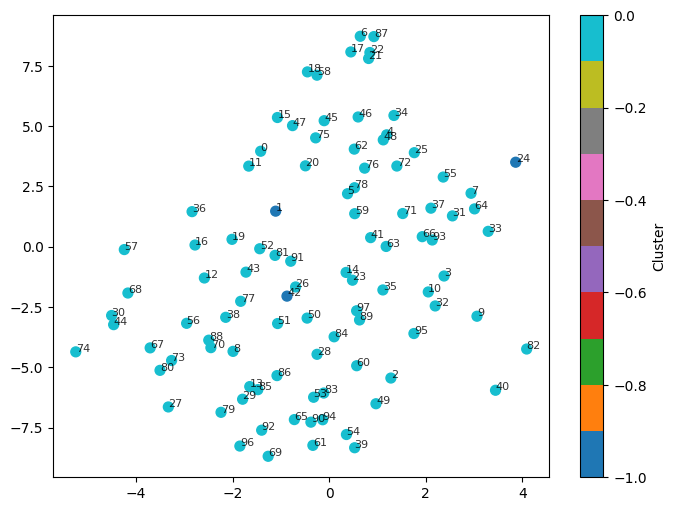

In [267]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_db, cmap='tab10', s=50)

for i in range(len(X_tsne)):
    plt.text(X_tsne[i, 0], X_tsne[i, 1], str(i), fontsize=8, alpha=0.8)

plt.colorbar(label="Cluster")
plt.show()

In [268]:
print("outlierzy:")
for ind in [1, 42, 24]:
    print(titles[ind])

outlierzy:
Grand Theft Auto IV Theme Song ＊[best quality]＊.mp3
SENTINO - Lato prod. CrackHouse.mp3
Czesław Niemen-Sen o Warszawie.mp3
